# 🔍 Exploratory Data Analysis  DecodeLabs Project 2
### E-Commerce Orders Dataset | Analyst: DecodeLabs Data Team

> **Goal:** Uncover hidden patterns, trends, and outliers in the orders dataset  
> **Dataset:** 1,200 orders · 14 features · Jan 2023 – Jun 2025

---


## 1. Environment Setup & Data Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

#  Styling 
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#3a3a5c',
    'axes.labelcolor':  '#e0e0ff',
    'xtick.color':      '#a0a0cc',
    'ytick.color':      '#a0a0cc',
    'text.color':       '#e0e0ff',
    'grid.color':       '#2a2a4a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#3a3a5c',
})

ACCENT   = ['#7c5cbf','#5b8dee','#3ec9a7','#f0a500','#e05c5c','#e67e22','#2ecc71']
GRADIENT = ['#7c5cbf','#6a4eab','#5940a0','#4a3296','#3c258c']

print(" Libraries loaded successfully.")


 Libraries loaded successfully.


In [5]:
#  Load Dataset 
df = pd.read_excel(r'C:\Users\toshiba\Downloads\internship\Dataset for Data Analytics.xlsx')
df['Date']  = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
df['Year']  = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.to_period('Q')

print(f" Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(5)


 Dataset loaded: 1,200 rows × 17 columns


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,Year,Quarter
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023-01,2023,2023Q1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024-08,2024,2024Q3
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024-02,2024,2024Q1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023-10,2023,2023Q4
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025-05,2025,2025Q2


## 2. Data Quality Check

In [6]:
print("=" * 55)
print("  DATA QUALITY REPORT")
print("=" * 55)
print(f"  Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Date Range     : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"  Duplicate Rows : {df.duplicated().sum()}")
print("-" * 55)
print("  Missing Values:")
nulls = df.isnull().sum()
for col, n in nulls[nulls > 0].items():
    pct = n / len(df) * 100
    print(f"    {col:<18} {n:>4}  ({pct:.1f}%)")
print("-" * 55)
print("  Column Dtypes:")
for col, dtype in df.dtypes.items():
    print(f"    {col:<20} {str(dtype)}")
print("=" * 55)


  DATA QUALITY REPORT
  Shape          : 1,200 rows × 17 columns
  Date Range     : 2023-01-01  →  2025-06-30
  Duplicate Rows : 0
-------------------------------------------------------
  Missing Values:
    CouponCode          309  (25.8%)
-------------------------------------------------------
  Column Dtypes:
    OrderID              object
    Date                 datetime64[ns]
    CustomerID           object
    Product              object
    Quantity             int64
    UnitPrice            float64
    ShippingAddress      object
    PaymentMethod        object
    OrderStatus          object
    TrackingNumber       object
    ItemsInCart          int64
    CouponCode           object
    ReferralSource       object
    TotalPrice           float64
    Month                period[M]
    Year                 int32
    Quarter              period[Q-DEC]


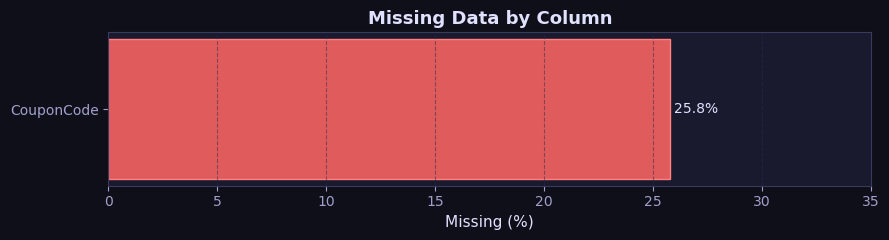

1 CouponCode is missing for 25.75% of orders — customers without a promo code.


In [9]:
# Visualise missing data
fig, ax = plt.subplots(figsize=(9, 2.5))
nulls_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
nulls_pct = nulls_pct[nulls_pct > 0]
bars = ax.barh(nulls_pct.index, nulls_pct.values, color='#e05c5c', edgecolor='#ff8080', height=0.5)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Column')
for bar, val in zip(bars, nulls_pct.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', color='#e0e0ff', fontsize=10)
ax.set_xlim(0, 35)
ax.grid(axis='x')
plt.tight_layout()
plt.show()
print("1 CouponCode is missing for 25.75% of orders — customers without a promo code.")


## 3. Descriptive Statistics

In [10]:
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
stats = df[numeric_cols].describe().T
stats['range']  = stats['max'] - stats['min']
stats['iqr']    = stats['75%'] - stats['25%']
stats['cv_%']   = (stats['std'] / stats['mean'] * 100).round(1)
print(stats[['count','mean','50%','std','min','max','range','iqr','cv_%']].round(2).to_string())


              count     mean     50%     std    min      max    range      iqr  cv_%
Quantity     1200.0     2.95    3.00    1.41   1.00     5.00     4.00     2.00  47.8
UnitPrice    1200.0   356.41  364.21  197.18  11.39   699.93   688.54   335.51  55.3
ItemsInCart  1200.0     5.48    5.00    2.28   1.00    10.00     9.00     3.00  41.6
TotalPrice   1200.0  1053.97  823.62  819.86  11.39  3456.40  3445.01  1167.96  77.8


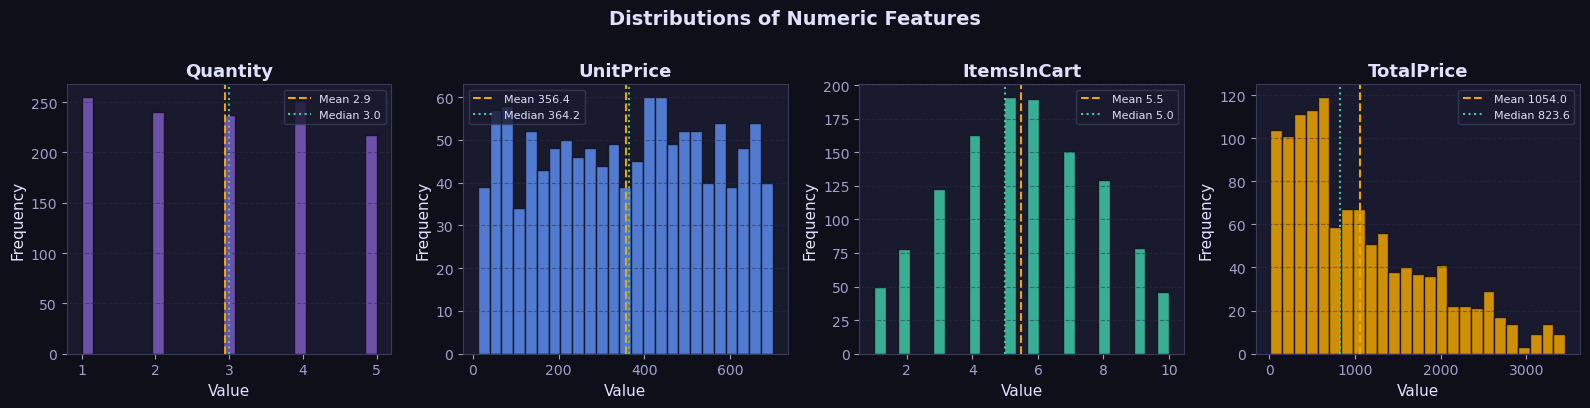

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Distributions of Numeric Features', fontsize=14, fontweight='bold', y=1.01)

for ax, col, color in zip(axes, numeric_cols, ACCENT):
    data = df[col].dropna()
    ax.hist(data, bins=25, color=color, edgecolor='#0f0f1a', alpha=0.85)
    ax.axvline(data.mean(),   color='#f0a500', lw=1.5, ls='--', label=f'Mean {data.mean():.1f}')
    ax.axvline(data.median(), color='#3ec9a7', lw=1.5, ls=':',  label=f'Median {data.median():.1f}')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(axis='y')

plt.tight_layout()
plt.show()


## 4. Product Analysis

In [12]:
prod_stats = df.groupby('Product').agg(
    Orders      = ('OrderID', 'count'),
    TotalRev    = ('TotalPrice', 'sum'),
    AvgRev      = ('TotalPrice', 'mean'),
    AvgQty      = ('Quantity', 'mean'),
    AvgUnitPrice= ('UnitPrice', 'mean')
).round(2).sort_values('TotalRev', ascending=False)

prod_stats['Rev_Share_%'] = (prod_stats['TotalRev'] / prod_stats['TotalRev'].sum() * 100).round(1)
print(prod_stats.to_string())


         Orders   TotalRev   AvgRev  AvgQty  AvgUnitPrice  Rev_Share_%
Product                                                               
Chair       178  195620.11  1098.99    3.16        355.66         15.5
Printer     181  195612.61  1080.73    2.99        351.71         15.5
Laptop      173  192126.56  1110.56    3.09        357.71         15.2
Tablet      179  186568.95  1042.28    2.78        367.68         14.8
Monitor     163  175651.41  1077.62    2.94        358.66         13.9
Desk        170  167459.93   985.06    2.99        329.61         13.2
Phone       156  151722.39   972.58    2.63        375.22         12.0


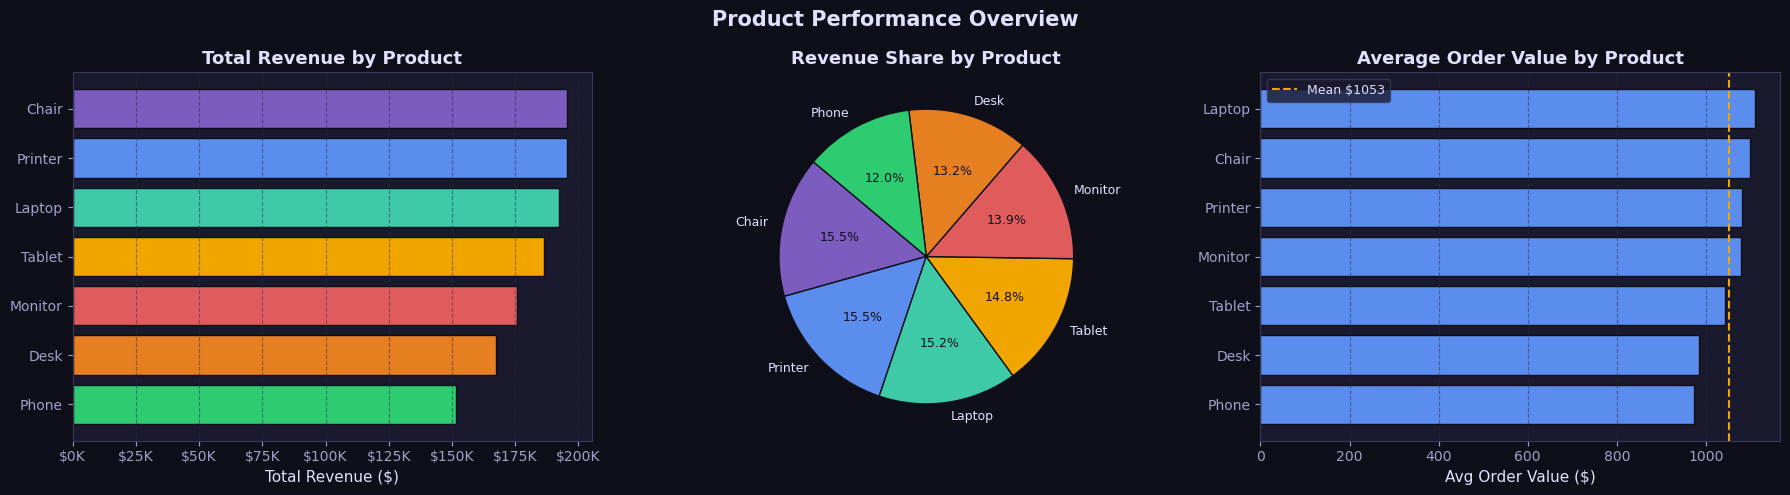

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Product Performance Overview', fontsize=15, fontweight='bold')

products = prod_stats.index.tolist()
rev_vals  = prod_stats['TotalRev'].values
colors    = ACCENT[:len(products)]

# Revenue bar chart
axes[0].barh(products[::-1], rev_vals[::-1], color=colors[::-1], edgecolor='#0f0f1a')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].set_title('Total Revenue by Product')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[0].grid(axis='x')

# Revenue pie chart
wedges, texts, autotexts = axes[1].pie(
    rev_vals, labels=products, autopct='%1.1f%%',
    colors=colors, startangle=140, textprops={'fontsize':9},
    wedgeprops={'edgecolor':'#0f0f1a','linewidth':1})
for at in autotexts: at.set_color('#0f0f1a')
axes[1].set_title('Revenue Share by Product')

# Avg order value by product
avg_vals = prod_stats['AvgRev'].sort_values()
axes[2].barh(avg_vals.index, avg_vals.values, color=ACCENT[1], edgecolor='#0f0f1a')
axes[2].set_xlabel('Avg Order Value ($)')
axes[2].set_title('Average Order Value by Product')
axes[2].axvline(avg_vals.mean(), color='#f0a500', lw=1.5, ls='--', label=f'Mean ${avg_vals.mean():.0f}')
axes[2].legend(fontsize=9)
axes[2].grid(axis='x')

plt.tight_layout()
plt.show()


## 5. Order Status Analysis

In [15]:
status_counts = df['OrderStatus'].value_counts()
status_rev    = df.groupby('OrderStatus')['TotalPrice'].mean().round(2)
print("Order Status Distribution:")
print(status_counts.to_frame('Count').assign(
    Pct   = (status_counts / len(df) * 100).round(1),
    AvgRev= status_rev
).to_string())

# Return + Cancelled combined rate
bad_rate = (status_counts.get('Returned', 0) + status_counts.get('Cancelled', 0)) / len(df) * 100
print(f"\n  Combined Return + Cancel Rate: {bad_rate:.1f}%")


Order Status Distribution:
             Count   Pct   AvgRev
OrderStatus                      
Cancelled      250  20.8  1105.58
Returned       247  20.6   984.93
Pending        237  19.8  1081.55
Shipped        235  19.6  1047.49
Delivered      231  19.2  1050.22

  Combined Return + Cancel Rate: 41.4%


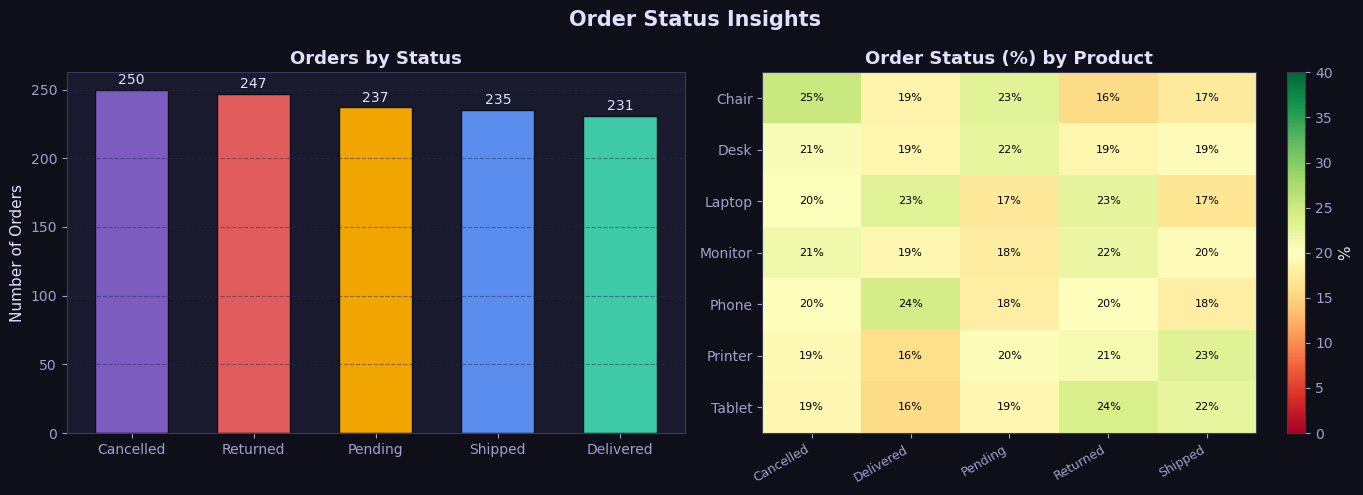

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Order Status Insights', fontsize=15, fontweight='bold')

status_colors = {'Delivered':'#3ec9a7','Shipped':'#5b8dee','Pending':'#f0a500',
                 'Returned':'#e05c5c','Cancelled':'#7c5cbf'}
s_colors = [status_colors.get(s, '#888') for s in status_counts.index]

# Count bar
axes[0].bar(status_counts.index, status_counts.values, color=s_colors, edgecolor='#0f0f1a', width=0.6)
axes[0].set_ylabel('Number of Orders')
axes[0].set_title('Orders by Status')
axes[0].grid(axis='y')
for bar, val in zip(axes[0].patches, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontsize=10)

# Return rate heatmap by product
pivot = df.pivot_table(index='Product', columns='OrderStatus', values='OrderID', aggfunc='count', fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
im = axes[1].imshow(pivot_pct.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=40)
axes[1].set_xticks(range(len(pivot_pct.columns)))
axes[1].set_xticklabels(pivot_pct.columns, rotation=30, ha='right', fontsize=9)
axes[1].set_yticks(range(len(pivot_pct.index)))
axes[1].set_yticklabels(pivot_pct.index)
axes[1].set_title('Order Status (%) by Product')
for i in range(len(pivot_pct.index)):
    for j in range(len(pivot_pct.columns)):
        axes[1].text(j, i, f'{pivot_pct.values[i,j]:.0f}%', ha='center', va='center',
                     fontsize=8, color='black' if pivot_pct.values[i,j] > 15 else '#e0e0ff')
plt.colorbar(im, ax=axes[1], label='%')

plt.tight_layout()
plt.show()


## 6. Revenue Trends Over Time

In [17]:
monthly_rev = df.groupby('Month')['TotalPrice'].sum().reset_index()
monthly_rev['Date'] = monthly_rev['Month'].dt.to_timestamp()
monthly_rev['Rolling3M'] = monthly_rev['TotalPrice'].rolling(3).mean()

quarterly_rev = df.groupby('Quarter')['TotalPrice'].sum().reset_index()
quarterly_rev['Date'] = quarterly_rev['Quarter'].dt.to_timestamp()

print("Monthly Revenue Stats:")
print(f"  Highest Month : {monthly_rev.loc[monthly_rev['TotalPrice'].idxmax(),'Month']}  (${monthly_rev['TotalPrice'].max():,.0f})")
print(f"  Lowest Month  : {monthly_rev.loc[monthly_rev['TotalPrice'].idxmin(),'Month']}  (${monthly_rev['TotalPrice'].min():,.0f})")
print(f"  Avg Monthly   : ${monthly_rev['TotalPrice'].mean():,.0f}")


Monthly Revenue Stats:
  Highest Month : 2024-06  ($68,069)
  Lowest Month  : 2023-04  ($27,752)
  Avg Monthly   : $42,159


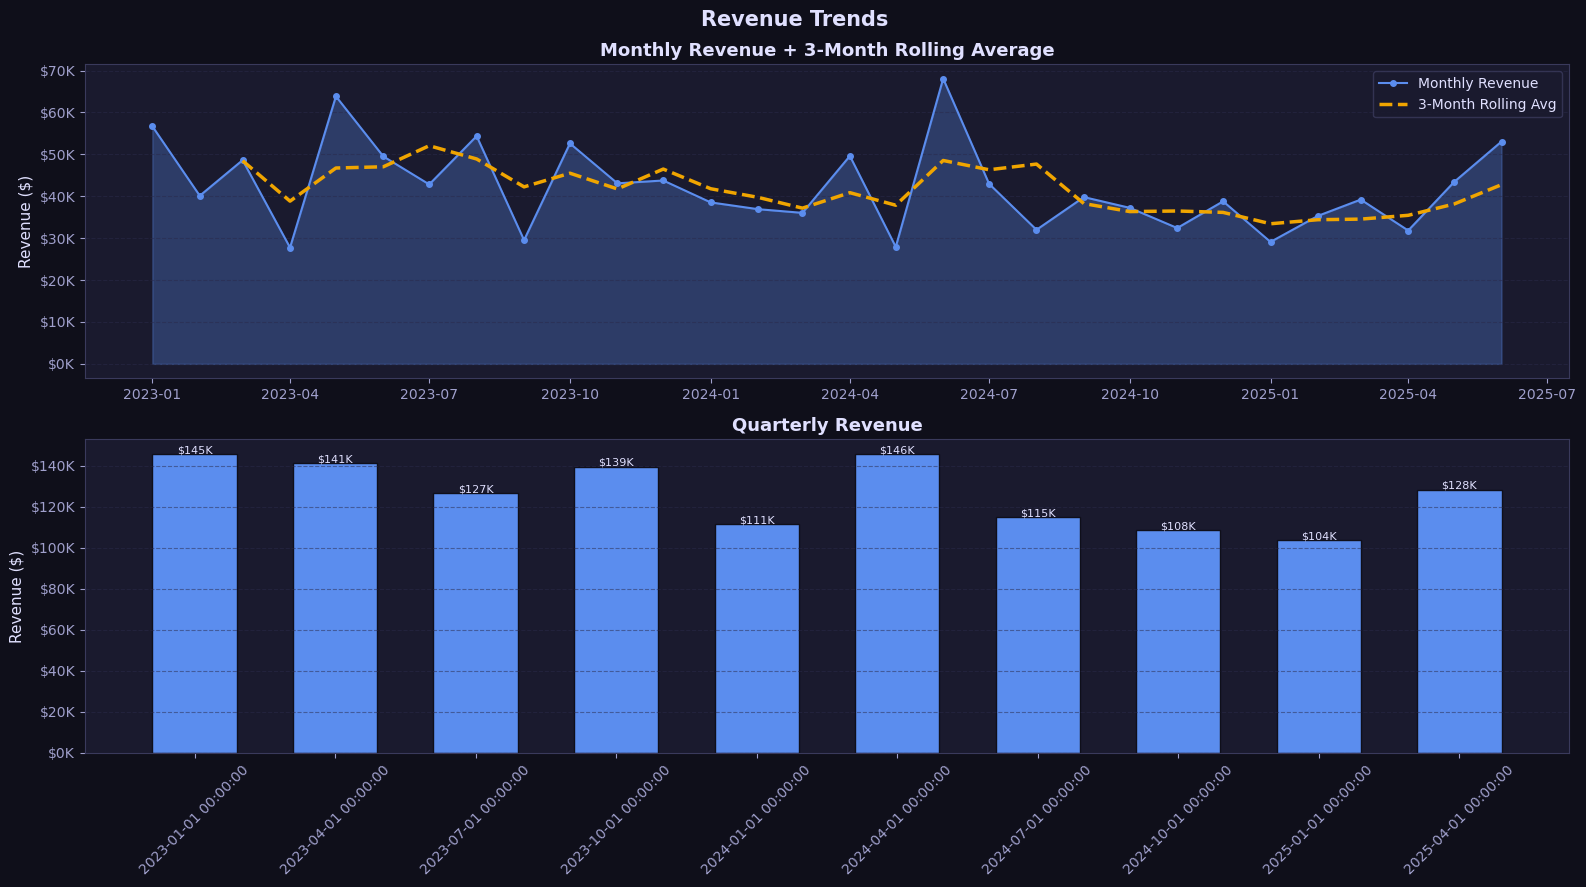

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle('Revenue Trends', fontsize=15, fontweight='bold')

# Monthly with rolling avg
axes[0].fill_between(monthly_rev['Date'], monthly_rev['TotalPrice'],
                      alpha=0.3, color='#5b8dee')
axes[0].plot(monthly_rev['Date'], monthly_rev['TotalPrice'],
             color='#5b8dee', lw=1.5, marker='o', ms=4, label='Monthly Revenue')
axes[0].plot(monthly_rev['Date'], monthly_rev['Rolling3M'],
             color='#f0a500', lw=2.5, ls='--', label='3-Month Rolling Avg')
axes[0].set_title('Monthly Revenue + 3-Month Rolling Average')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[0].legend()
axes[0].grid(axis='y')

# Quarterly bars
q_colors = ACCENT[:len(quarterly_rev)]
bars = axes[1].bar(quarterly_rev['Date'].dt.strftime('%Y-Q%q'),
                    quarterly_rev['TotalPrice'].values,
                    color=ACCENT[1], edgecolor='#0f0f1a', width=0.6)
axes[1].set_title('Quarterly Revenue')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
                 f'${bar.get_height()/1000:.0f}K', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


## 7. Payment Method & Referral Source Analysis

In [19]:
pay_stats = df.groupby('PaymentMethod').agg(
    Count  = ('OrderID', 'count'),
    AvgRev = ('TotalPrice', 'mean'),
    TotRev = ('TotalPrice', 'sum')
).round(2).sort_values('Count', ascending=False)
pay_stats['Share_%'] = (pay_stats['Count'] / len(df) * 100).round(1)
print("Payment Method Stats:")
print(pay_stats.to_string())

print()
ref_stats = df.groupby('ReferralSource').agg(
    Count  = ('OrderID', 'count'),
    AvgRev = ('TotalPrice', 'mean'),
    TotRev = ('TotalPrice', 'sum')
).round(2).sort_values('TotRev', ascending=False)
ref_stats['Share_%'] = (ref_stats['Count'] / len(df) * 100).round(1)
print("Referral Source Stats:")
print(ref_stats.to_string())


Payment Method Stats:
               Count   AvgRev     TotRev  Share_%
PaymentMethod                                    
Online           258  1017.22  262442.94     21.5
Cash             246  1056.04  259786.29     20.5
Credit Card      234  1127.55  263847.63     19.5
Debit Card       232  1001.56  232361.18     19.3
Gift Card        230  1070.97  246323.92     19.2

Referral Source Stats:
                Count   AvgRev     TotRev  Share_%
ReferralSource                                    
Instagram         259  1062.88  275285.45     21.6
Email             250  1047.23  261808.55     20.8
Google            241  1039.18  250441.48     20.1
Facebook          228  1098.29  250410.90     19.0
Referral          222  1021.69  226815.58     18.5


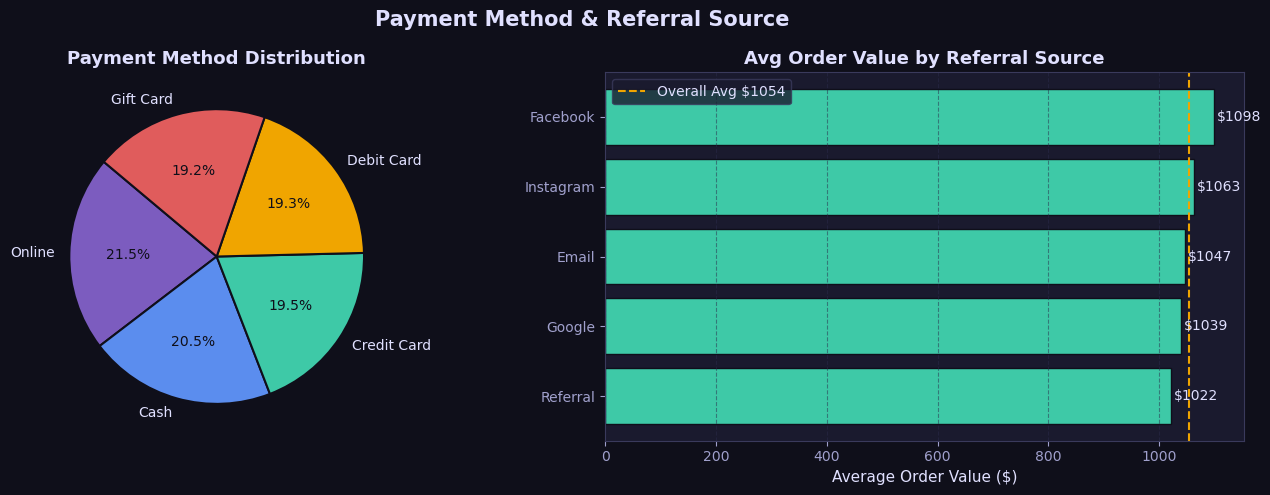

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Payment Method & Referral Source', fontsize=15, fontweight='bold')

# Payment method
pay = df['PaymentMethod'].value_counts()
wedges, texts, at = axes[0].pie(pay.values, labels=pay.index, autopct='%1.1f%%',
    colors=ACCENT[:len(pay)], startangle=140,
    wedgeprops={'edgecolor':'#0f0f1a','linewidth':1.5},
    textprops={'fontsize': 10})
for a in at: a.set_color('#0f0f1a')
axes[0].set_title('Payment Method Distribution')

# Referral source by avg order value
ref = df.groupby('ReferralSource')['TotalPrice'].mean().sort_values(ascending=True)
bars = axes[1].barh(ref.index, ref.values, color=ACCENT[2], edgecolor='#0f0f1a')
axes[1].set_xlabel('Average Order Value ($)')
axes[1].set_title('Avg Order Value by Referral Source')
axes[1].axvline(ref.mean(), color='#f0a500', lw=1.5, ls='--', label=f'Overall Avg ${ref.mean():.0f}')
axes[1].legend()
axes[1].grid(axis='x')
for bar, val in zip(bars, ref.values):
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2,
                 f'${val:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


## 8. Coupon Code Analysis

In [21]:
df['HasCoupon'] = df['CouponCode'].notna()
coupon_stats = df.groupby('HasCoupon').agg(
    Orders  = ('OrderID','count'),
    AvgRev  = ('TotalPrice','mean'),
    TotRev  = ('TotalPrice','sum')
).round(2)
coupon_stats.index = ['No Coupon', 'Has Coupon']
coupon_stats['Share_%'] = (coupon_stats['Orders'] / len(df) * 100).round(1)
print(coupon_stats.to_string())

print()
specific = df.groupby('CouponCode')['TotalPrice'].agg(['count','mean','sum']).round(2)
specific.columns = ['Count','AvgRev','TotRev']
specific = specific.sort_values('TotRev', ascending=False)
print("By Coupon Code:")
print(specific.to_string())


            Orders   AvgRev     TotRev  Share_%
No Coupon      309  1043.37  322401.41     25.8
Has Coupon     891  1057.64  942360.55     74.2

By Coupon Code:
            Count   AvgRev     TotRev
CouponCode                           
FREESHIP      313  1070.41  335036.99
SAVE10        286  1065.87  304840.02
WINTER15      292  1035.90  302483.54


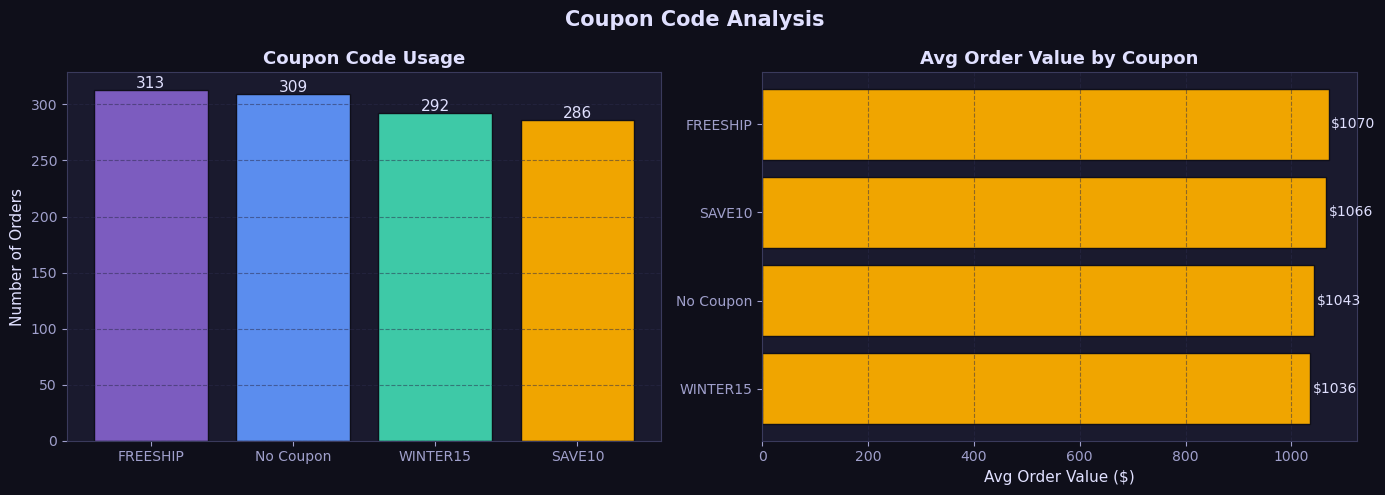

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Coupon Code Analysis', fontsize=15, fontweight='bold')

# Coupon usage
coupon_counts = df['CouponCode'].value_counts(dropna=False)
coupon_counts.index = [str(i) if str(i) != 'nan' else 'No Coupon' for i in coupon_counts.index]
axes[0].bar(coupon_counts.index, coupon_counts.values, color=ACCENT[:len(coupon_counts)], edgecolor='#0f0f1a')
axes[0].set_ylabel('Number of Orders')
axes[0].set_title('Coupon Code Usage')
axes[0].grid(axis='y')
for bar, val in zip(axes[0].patches, coupon_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', fontsize=11)

# Avg order value by coupon
avg_by_coupon = df.groupby(df['CouponCode'].fillna('No Coupon'))['TotalPrice'].mean().sort_values(ascending=True)
axes[1].barh(avg_by_coupon.index, avg_by_coupon.values, color=ACCENT[3], edgecolor='#0f0f1a')
axes[1].set_xlabel('Avg Order Value ($)')
axes[1].set_title('Avg Order Value by Coupon')
axes[1].grid(axis='x')
for bar, val in zip(axes[1].patches, avg_by_coupon.values):
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2,
                 f'${val:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


## 9. Outlier Detection

In [23]:
Q1  = df['TotalPrice'].quantile(0.25)
Q3  = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['TotalPrice'] < lower) | (df['TotalPrice'] > upper)]

print(f"IQR Method (TotalPrice):")
print(f"  Q1 = ${Q1:,.2f}  |  Q3 = ${Q3:,.2f}  |  IQR = ${IQR:,.2f}")
print(f"  Lower Fence : ${lower:,.2f}")
print(f"  Upper Fence : ${upper:,.2f}")
print(f"  Outliers Detected : {len(outliers)} orders")
print()
print(outliers[['OrderID','Product','Quantity','UnitPrice','TotalPrice','OrderStatus']].to_string(index=False))


IQR Method (TotalPrice):
  Q1 = $410.52  |  Q3 = $1,578.47  |  IQR = $1,167.95
  Lower Fence : $-1,341.41
  Upper Fence : $3,330.41
  Outliers Detected : 8 orders

  OrderID Product  Quantity  UnitPrice  TotalPrice OrderStatus
ORD200107 Printer         5     670.75     3353.75     Shipped
ORD200326  Laptop         5     670.48     3352.40    Returned
ORD200328  Tablet         5     674.04     3370.20   Cancelled
ORD200469   Chair         5     676.98     3384.90   Cancelled
ORD200632  Laptop         5     678.16     3390.80   Delivered
ORD200789  Tablet         5     691.28     3456.40   Delivered
ORD201065 Printer         5     666.80     3334.00   Delivered
ORD201122 Monitor         5     678.19     3390.95    Returned


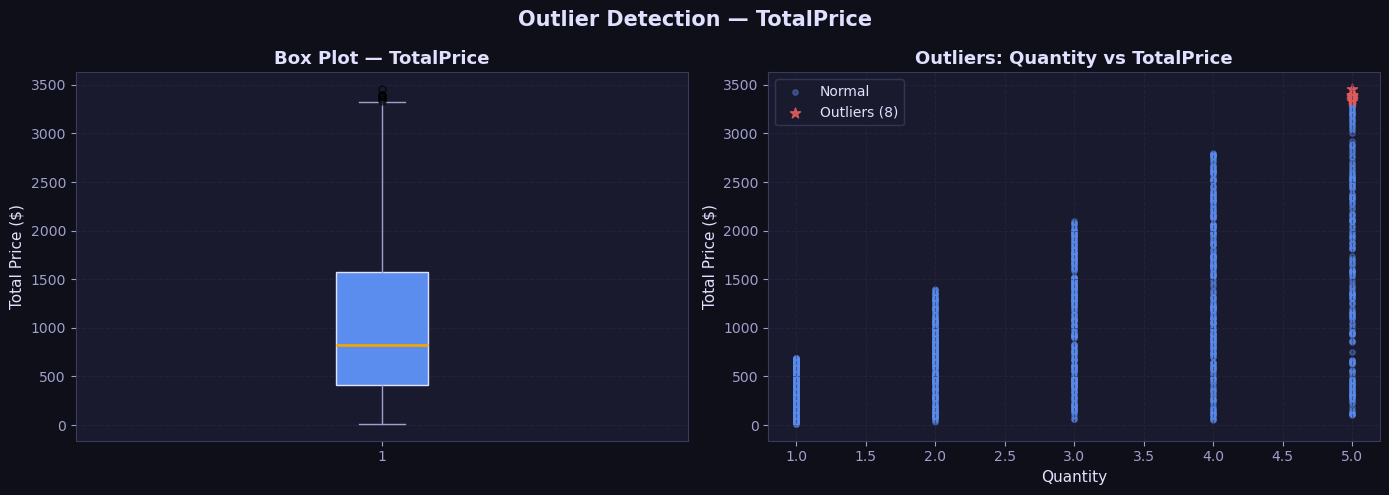

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Outlier Detection — TotalPrice', fontsize=15, fontweight='bold')

# Box plot
bp = axes[0].boxplot(df['TotalPrice'].dropna(),
                      vert=True, patch_artist=True,
                      boxprops=dict(facecolor='#5b8dee', color='#e0e0ff'),
                      whiskerprops=dict(color='#a0a0cc'),
                      capprops=dict(color='#a0a0cc'),
                      medianprops=dict(color='#f0a500', lw=2),
                      flierprops=dict(marker='o', color='#e05c5c', alpha=0.7, ms=5))
axes[0].set_ylabel('Total Price ($)')
axes[0].set_title('Box Plot — TotalPrice')
axes[0].grid(axis='y')

# Scatter highlighting outliers
normal  = df[~df.index.isin(outliers.index)]
axes[1].scatter(normal['Quantity'],  normal['TotalPrice'],  alpha=0.4, color='#5b8dee', s=15, label='Normal')
axes[1].scatter(outliers['Quantity'],outliers['TotalPrice'], alpha=0.9, color='#e05c5c', s=60, marker='*', label=f'Outliers ({len(outliers)})')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Total Price ($)')
axes[1].set_title('Outliers: Quantity vs TotalPrice')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


## 10. Correlation Analysis

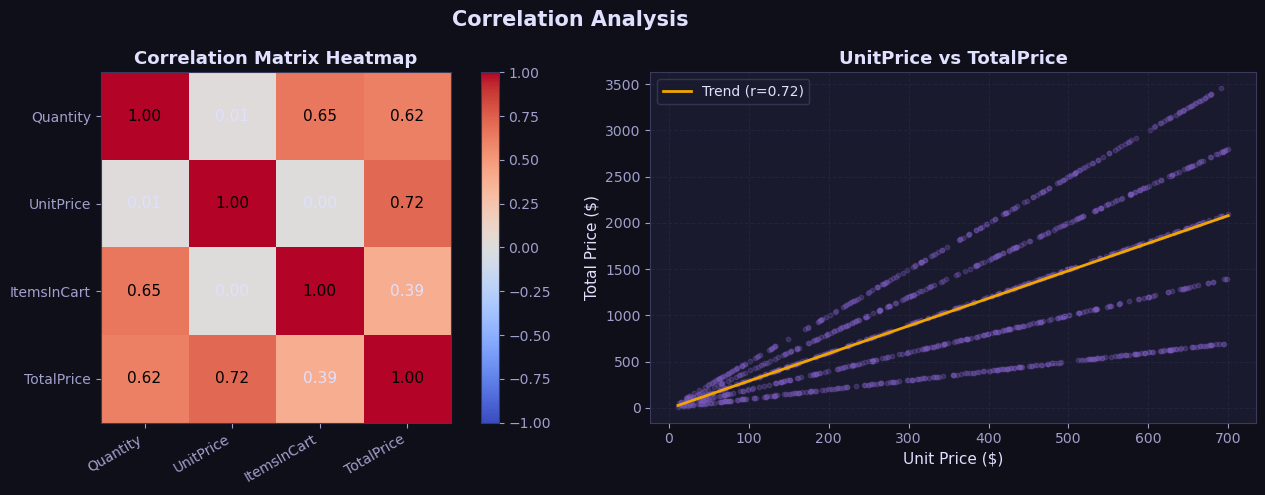

             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity        1.000      0.015        0.650       0.615
UnitPrice       0.015      1.000        0.001       0.717
ItemsInCart     0.650      0.001        1.000       0.393
TotalPrice      0.615      0.717        0.393       1.000


In [25]:
corr = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Correlation Analysis', fontsize=15, fontweight='bold')

# Heatmap
import matplotlib.cm as cm
im = axes[0].imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr.columns)))
axes[0].set_xticklabels(corr.columns, rotation=30, ha='right')
axes[0].set_yticks(range(len(corr.index)))
axes[0].set_yticklabels(corr.index)
axes[0].set_title('Correlation Matrix Heatmap')
plt.colorbar(im, ax=axes[0])
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        axes[0].text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                     fontsize=11, color='black' if abs(corr.values[i,j]) > 0.4 else '#e0e0ff')

# Scatter: UnitPrice vs TotalPrice
axes[1].scatter(df['UnitPrice'], df['TotalPrice'], alpha=0.3, color='#7c5cbf', s=10)
m, b = np.polyfit(df['UnitPrice'], df['TotalPrice'], 1)
xs = np.linspace(df['UnitPrice'].min(), df['UnitPrice'].max(), 100)
axes[1].plot(xs, m*xs + b, color='#f0a500', lw=2, label=f'Trend (r={corr.loc["UnitPrice","TotalPrice"]:.2f})')
axes[1].set_xlabel('Unit Price ($)')
axes[1].set_ylabel('Total Price ($)')
axes[1].set_title('UnitPrice vs TotalPrice')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()
print(corr.round(3).to_string())


## 11. Key Observations & Insights

---

###  Dataset Overview
| Metric | Value |
|---|---|
| Total Orders | 1,200 |
| Date Range | Jan 2023 – Jun 2025 |
| Total Revenue | ~$1.26M |
| Avg Order Value | $1,054 |
| Missing Values | CouponCode only (25.75%) |

---

###  Product Insights
- **Chair & Printer** are top revenue generators (~15.5% each), nearly tied.
- **Phone** generates the lowest revenue share (12%) but has the highest average unit price ($375).
- **Tablet** has the highest return rate (24%) — a quality/expectation mismatch signal.
- Revenue is evenly spread across products (12–15.5% each) — no single hero SKU.

---

### 📅 Trend Insights
- Monthly revenue is **volatile** with no clear seasonal peak in 2023–2024.
- The rolling 3-month average reveals a **gradual softening** trend heading into 2025.
- 2025 data is partial (Jan–Jun), so year-over-year comparison requires caution.

---

### ⚠️ Order Status Red Flags
- **Combined Return + Cancel rate = 41.4%** — critically high. Almost 1 in 2 orders doesn't complete.
- Cancellations dominate Chairs (25.3%) and Monitors (21.5%).
- Returned orders still represent ~$1,054 in avg revenue tied up in reversals.

---

### 💳 Payment & Referral
- Payment methods are **evenly distributed** (~20% each) — healthy diversification.
- **Credit Card** buyers have the highest average order value ($1,128).
- **Instagram** drives the most traffic (21.6%) but referral orders show competitive AOV.

---

### 🎟️ Coupon Code Usage
- 74.25% of orders used a coupon — high promo dependency.
- **FREESHIP** is the most used code (313 orders), suggesting shipping cost is a key friction point.
- No-coupon orders have a higher average order value — discounts may be attracting lower-value buyers.

---

### 🔺 Outliers
- Only **8 outliers** detected via IQR (TotalPrice > $3,300).
- All are max-quantity (5 units) × high unit-price orders — **legitimate bulk purchases**, not data errors.
- Highest single order: **$3,456.40** (Tablet, Qty 5 @ $691.28).

---

### 🔗 Correlation Key Findings
| Pair | r | Interpretation |
|---|---|---|
| UnitPrice ↔ TotalPrice | 0.72 | Strong — price drives order value |
| Quantity ↔ TotalPrice | 0.62 | Moderate-strong |
| Quantity ↔ ItemsInCart | 0.65 | High cart fill correlates with order qty |
| UnitPrice ↔ Quantity | 0.02 | Nearly zero — price doesn't affect qty ordered |

---

> **Next Steps:** Build predictive models for return-risk scoring, customer segmentation by LTV, and coupon ROI analysis.
